In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os

# Wczytaj dane
BASE_DIR = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
CSV_PATH = os.path.join(BASE_DIR, "data", "posture_data.csv")

df = pd.read_csv(CSV_PATH)

print(f"Kształt danych: {df.shape}")
print(f"\nRozkład klas:")
print(df["label"].value_counts())
print(f"\nCzy są NULLe: {df.isnull().sum().sum()}")
df.head()

Kształt danych: (3247, 22)

Rozkład klas:
label
1    1773
0    1474
Name: count, dtype: int64

Czy są NULLe: 0


,nose_x,nose_y,nose_z,left_eye_x,left_eye_y,left_eye_z,right_eye_x,right_eye_y,right_eye_z,left_ear_x,...,right_ear_x,right_ear_y,right_ear_z,left_shoulder_x,left_shoulder_y,left_shoulder_z,right_shoulder_x,right_shoulder_y,right_shoulder_z,label
0,0.424267,0.615120,-0.951750,0.454850,0.572726,-0.896501,0.392089,0.572971,-0.903984,0.480012,...,0.367513,0.596853,-0.554099,0.581266,0.852838,-0.247234,0.260975,0.842719,-0.320900,0
1,0.423372,0.609551,-0.974897,0.453784,0.569608,-0.924132,0.391366,0.569014,-0.930322,0.478290,...,0.367235,0.593481,-0.574879,0.579804,0.835874,-0.268576,0.260699,0.842145,-0.373632,0
2,0.422889,0.609917,-0.880332,0.453097,0.569267,-0.831261,0.390752,0.569401,-0.831060,0.477529,...,0.366473,0.594441,-0.471080,0.579647,0.831362,-0.234378,0.263449,0.838536,-0.268100,0
3,0.422416,0.609953,-0.856059,0.452765,0.569189,-0.810274,0.390341,0.569444,-0.812437,0.477357,...,0.366195,0.594529,-0.482871,0.581585,0.835240,-0.241231,0.263919,0.836590,-0.278230,0
4,0.422153,0.609858,-0.872530,0.452764,0.569308,-0.824061,0.390233,0.569153,-0.828815,0.477910,...,0.366122,0.594220,-0.523375,0.583907,0.846804,-0.288597,0.263034,0.839703,-0.312495,0


In [2]:
# Oddziel cechy od etykiet
X = df.drop("label", axis=1)
y = df["label"]

print(f"Liczba cech: {X.shape[1]}")
print(f"Nazwy cech: {list(X.columns)}")

# Podział na zbiór treningowy i testowy (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Skalowanie (ważne dla SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTreningowe: {X_train.shape}")
print(f"Testowe:    {X_test.shape}")

Liczba cech: 21
Nazwy cech: ['nose_x', 'nose_y', 'nose_z', 'left_eye_x', 'left_eye_y', 'left_eye_z', 'right_eye_x', 'right_eye_y', 'right_eye_z', 'left_ear_x', 'left_ear_y', 'left_ear_z', 'right_ear_x', 'right_ear_y', 'right_ear_z', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z']

Treningowe: (2597, 21)
Testowe:    (650, 21)


In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)  # RF nie wymaga skalowania

y_pred_rf = rf_model.predict(X_test)

print("=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Dobra", "Zla"]))

=== RANDOM FOREST ===
Accuracy: 0.9877

Classification Report:
              precision    recall  f1-score   support

       Dobra       0.99      0.98      0.99       295
         Zla       0.98      0.99      0.99       355

    accuracy                           0.99       650
   macro avg       0.99      0.99      0.99       650
weighted avg       0.99      0.99      0.99       650



In [4]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)  # SVM wymaga skalowania

y_pred_svm = svm_model.predict(X_test_scaled)

print("=== SVM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=["Dobra", "Zla"]))

=== SVM ===
Accuracy: 0.9862

Classification Report:
              precision    recall  f1-score   support

       Dobra       0.98      0.99      0.98       295
         Zla       0.99      0.99      0.99       355

    accuracy                           0.99       650
   macro avg       0.99      0.99      0.99       650
weighted avg       0.99      0.99      0.99       650



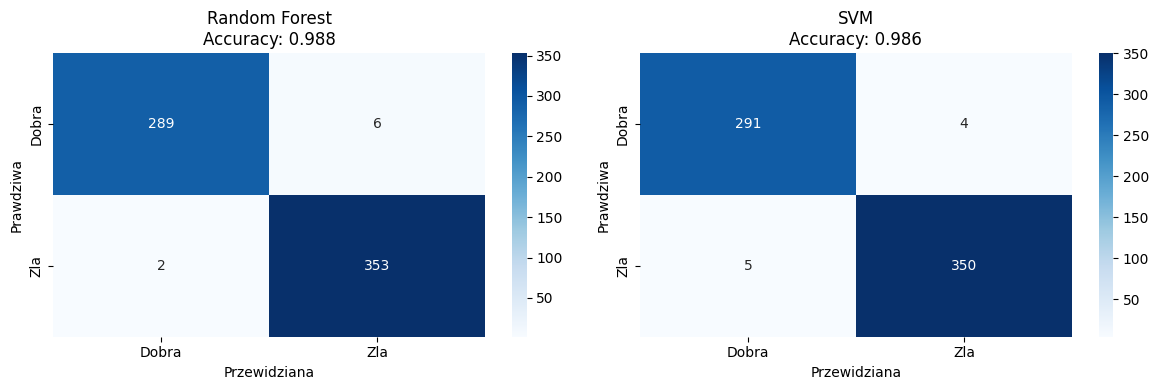

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [
    ("Random Forest", y_pred_rf),
    ("SVM",           y_pred_svm)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Dobra", "Zla"],
                yticklabels=["Dobra", "Zla"])
    ax.set_title(f"{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
    ax.set_ylabel("Prawdziwa")
    ax.set_xlabel("Przewidziana")

plt.tight_layout()
plt.show()

In [6]:
# Porównaj i zapisz lepszy model
rf_acc  = accuracy_score(y_test, y_pred_rf)
svm_acc = accuracy_score(y_test, y_pred_svm)

MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

if rf_acc >= svm_acc:
    best_name  = "Random Forest"
    joblib.dump(rf_model, os.path.join(MODELS_DIR, "posture_model.pkl"))
    joblib.dump(scaler,   os.path.join(MODELS_DIR, "scaler.pkl"))  # na wszelki wypadek
    print(f"✅ Zapisano Random Forest (accuracy: {rf_acc:.4f})")
else:
    best_name  = "SVM"
    joblib.dump(svm_model, os.path.join(MODELS_DIR, "posture_model.pkl"))
    joblib.dump(scaler,    os.path.join(MODELS_DIR, "scaler.pkl"))
    print(f"✅ Zapisano SVM (accuracy: {svm_acc:.4f})")

print(f"\nNajlepszy model: {best_name}")
print(f"Pliki zapisane w: {MODELS_DIR}")

✅ Zapisano Random Forest (accuracy: 0.9877)

Najlepszy model: Random Forest
Pliki zapisane w: C:\Users\emilk\PycharmProjects\PythonProject\models
